# Explore `train.csv`

`data/raw/train.csv` を観察するための notebook です。

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)


In [ ]:
ROOT = Path.cwd().parent
TRAIN_PATH = ROOT / "data/raw/train.csv"

print(f"ROOT: {ROOT}")
print(f"TRAIN_PATH: {TRAIN_PATH}")


ROOT: /Users/hikaru/kaggle/llm-classification-finetuning
TRAIN_PATH: /Users/hikaru/kaggle/llm-classification-finetuning/data/raw/train.csv


In [3]:
df = pd.read_csv(TRAIN_PATH)
print(df.shape)
display(df.head(3))
display(df.dtypes.to_frame("dtype"))


(57477, 9)


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain percentage of females on managerial positions?"",""OK, does pineapple b...","[""The question of whether it is morally right to aim for a certain percentage of females in managerial positions is ...","[""As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question of gender quotas in...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage license and marriage certificate?"",""How can I get both of them as quick as...","[""A marriage license is a legal document that allows a couple to get married. It is issued by a government agency, s...","[""A marriage license and a marriage certificate are two different legal documents that have separate purposes.\n\n1....",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call a function?""]","[""Function calling is the process of invoking or executing a function in a programming language. To call a function,...","[""Function calling is the process of invoking a function in a program. A function is a block of code that performs a...",0,0,1


,dtype
id,int64
model_a,str
model_b,str
prompt,str
response_a,str
response_b,str
winner_model_a,int64
winner_model_b,int64
winner_tie,int64


In [7]:
json_columns = ["prompt", "response_a", "response_b"]
parsed = df.copy()

for col in json_columns:
    parsed[col] = parsed[col].apply(json.loads)

def total_chars(xs: list[str | None]) -> int:
    return sum(len(x or "") for x in xs)

parsed["winner"] = (
    parsed[["winner_model_a", "winner_model_b", "winner_tie"]]
    .idxmax(axis=1)
    .map(
        {
            "winner_model_a": "model_a",
            "winner_model_b": "model_b",
            "winner_tie": "tie",
        }
    )
)
parsed["turn_count"] = parsed["prompt"].apply(len)
parsed["model_a_name"] = parsed["model_a"]
parsed["model_b_name"] = parsed["model_b"]
parsed["prompt_chars"] = parsed["prompt"].apply(total_chars)
parsed["response_a_chars"] = parsed["response_a"].apply(total_chars)
parsed["response_b_chars"] = parsed["response_b"].apply(total_chars)

parsed[["id", "winner", "turn_count", "prompt_chars", "response_a_chars", "response_b_chars"]].head()


,id,winner,turn_count,prompt_chars,response_a_chars,response_b_chars
0,30192,model_a,2,158,4458,1199
1,53567,model_b,3,190,3094,3590
2,65089,tie,1,56,884,1790
3,96401,model_a,1,83,3165,1550
4,198779,model_b,1,75,1290,760


In [8]:
summary = pd.DataFrame(
    {
        "rows": [len(parsed)],
        "unique_model_a": [parsed["model_a_name"].nunique()],
        "unique_model_b": [parsed["model_b_name"].nunique()],
        "unique_models_total": [pd.unique(pd.concat([parsed["model_a_name"], parsed["model_b_name"]])).size],
        "avg_turn_count": [parsed["turn_count"].mean()],
        "median_turn_count": [parsed["turn_count"].median()],
    }
)

display(summary.round(2))
display(parsed["winner"].value_counts().rename_axis("winner").to_frame("count"))
display(parsed["turn_count"].value_counts().sort_index().rename_axis("turn_count").to_frame("count").head(15))


,rows,unique_model_a,unique_model_b,unique_models_total,avg_turn_count,median_turn_count
0,57477,64,64,64,1.24,1.0


,count
winner,
model_a,20064
model_b,19652
tie,17761


,count
turn_count,
1,49938
2,4673
3,1485
4,607
5,311
6,167
7,103
8,60
9,44


,prompt_chars,response_chars
count,57477.0,57477.0
mean,352.1,1333.5
std,1025.3,1373.5
min,3.0,0.0
50%,91.0,1060.5
90%,757.0,2571.2
95%,1419.0,3380.0
99%,4697.8,6476.6
max,32829.0,37075.5


,prompt_chars,response_chars
mean,352.1,1333.5
median,91.0,1060.5
min,3.0,0.0
max,32829.0,37075.5


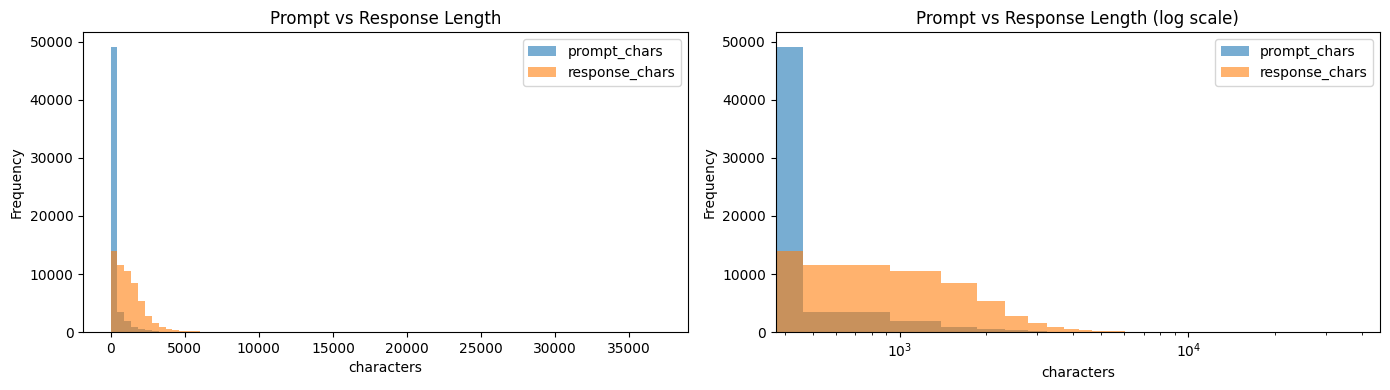

,appearances
model,
gpt-4-1106-preview,7387
gpt-3.5-turbo-0613,7083
gpt-4-0613,6165
claude-2.1,5583
claude-instant-1,4136
gpt-4-0314,4122
claude-1,3978
vicuna-33b,3720
mixtral-8x7b-instruct-v0.1,3545


In [11]:
import matplotlib.pyplot as plt

parsed["response_chars"] = parsed[["response_a_chars", "response_b_chars"]].mean(axis=1)

length_stats = (
    parsed[["prompt_chars", "response_chars"]]
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    .round(1)
)
display(length_stats)

distribution_summary = (
    parsed[["prompt_chars", "response_chars"]]
    .agg(["mean", "median", "min", "max"])
    .round(1)
)
display(distribution_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
parsed[["prompt_chars", "response_chars"]].plot.hist(bins=80, alpha=0.6, ax=axes[0])
axes[0].set_title("Prompt vs Response Length")
axes[0].set_xlabel("characters")

parsed[["prompt_chars", "response_chars"]].plot.hist(bins=80, alpha=0.6, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Prompt vs Response Length (log scale)")
axes[1].set_xlabel("characters")

plt.tight_layout()
plt.show()

model_usage = (
    pd.concat(
        [
            parsed["model_a_name"].rename("model"),
            parsed["model_b_name"].rename("model"),
        ],
        ignore_index=True,
    )
    .value_counts()
    .rename_axis("model")
    .to_frame("appearances")
)
display(model_usage.head(20))


In [10]:
sample_columns = [
    "id",
    "model_a_name",
    "model_b_name",
    "winner",
    "turn_count",
    "prompt",
    "response_a",
    "response_b",
]

sampled = parsed[sample_columns].sample(3, random_state=42)
for row in sampled.itertuples(index=False):
    display(Markdown(f"## id={row.id} | {row.model_a_name} vs {row.model_b_name} | winner={row.winner}"))
    for turn_idx, prompt_text in enumerate(row.prompt, start=1):
        display(Markdown(f"### Turn {turn_idx}"))
        display(Markdown(f"**Prompt**\n\n{prompt_text}"))
        display(Markdown(f"**Response A**\n\n{row.response_a[turn_idx - 1]}"))
        display(Markdown(f"**Response B**\n\n{row.response_b[turn_idx - 1]}"))


## id=2785062085 | gpt-3.5-turbo-0613 vs codellama-34b-instruct | winner=model_a

### Turn 1

**Prompt**

what does hello world mean

**Response A**

"Hello, World!" is a phrase used in computer programming to introduce beginners to a new programming language. It is often the first program that a programmer writes when learning a new language. The program typically displays the words "Hello, World!" on the screen or console. It serves as a basic starting point to verify that the programming environment is set up correctly and to demonstrate the basic syntax of the language.

**Response B**

"Hello, World!" is a common phrase used to display a message on a computer screen. It is often used as a simple test to ensure that a computer program or system is working correctly. When a computer program is executed, it will typically print "Hello, World!" to the screen, indicating that the program has been executed successfully.

...

## id=3622731894 | gpt-4-0314 vs gpt-3.5-turbo-0314 | winner=tie

### Turn 1

**Prompt**

Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:根据提供的产品风格特征，生成合适的产品文案评论。

### Input:[['类型', '裤'], ['颜色', '纯色'], ['图案', '刺绣'], ['图案', '纯色'], ['裤长', '五分裤']]

### Response:

**Response A**

这款纯色五分裤设计简约大方，采用精美的刺绣图案，展现出独特的时尚魅力。裤子的质感舒适，穿着轻松自在，是夏日搭配的不二之选。无论是休闲还是日常穿着，都能展现出您的个性与品味。

**Response B**

根据提供的产品风格特征，可以生成如下的产品文案评论：

这款五分裤采用纯色设计，搭配精致的刺绣图案，展现出时尚与个性的完美结合。舒适的面料和合身的剪裁，让您在穿着时感受到无与伦比的舒适感。无论是搭配休闲T恤还是正式衬衫，都能展现出您的独特品味和时尚态度。

In [11]:
parsed[["id", "winner", "turn_count", "model_a_name", "model_b_name"]].query("winner == 'tie'").head(10)


,id,winner,turn_count,model_a_name,model_b_name
2,65089,tie,1,gpt-3.5-turbo-0613,mistral-medium
14,862324,tie,1,vicuna-13b,koala-13b
18,933555,tie,1,llama-2-13b-chat,claude-instant-1
20,1256092,tie,1,claude-2.1,vicuna-13b
22,1440765,tie,1,llama2-70b-steerlm-chat,gpt-4-0125-preview
23,1458108,tie,1,claude-instant-1,wizardlm-13b
24,1491225,tie,1,claude-1,gpt-4-1106-preview
25,1594211,tie,1,dolly-v2-12b,alpaca-13b
26,1639617,tie,1,mixtral-8x7b-instruct-v0.1,gpt-4-0613
29,1827787,tie,1,deepseek-llm-67b-chat,gpt-4-1106-preview
